# Salary prediction, episode II: make it actually work (4 points)

Your main task is to use some of the tricks you've learned on the network and analyze if you can improve __validation MAE__. Try __at least 3 options__ from the list below for a passing grade. Write a short report about what you have tried. More ideas = more bonus points.

__Please be serious:__ " plot learning curves in MAE/epoch, compare models based on optimal performance, test one change at a time. You know the drill :)

You can use either __pytorch__ or __tensorflow__ or any other framework (e.g. pure __keras__). Feel free to adapt the seminar code for your needs. For tensorflow version, consider `seminar_tf2.ipynb` as a starting point.


## Seminar: Large scale text analysis with deep learning (3 points)

In this assignment, you will develop a deep learning model to predict salaries based on resumes (credits to to [Oleg Vasilev](https://github.com/Omrigan/)). While we will begin this project during our seminar class, it will require additional effort on your part to finalize and submit it as homework.

Following this, there is a supplementary task in another notebook titled homework_part2.ipynb. In this task, you are expected to conduct a more extensive study. This will involve testing various architectures to optimize prediction accuracy.

To secure full marks for this assignment, ensure a consistent training process with an MSE loss falling below 0.10. If necessary, feel free to experiment with different parameters and model architectures. If you achieve the desired results in the homework_part2.ipynb, you can either replicate your solution here or reference it explicitly in the comments when you submit.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

### About the challenge
For starters, let's download and unpack the data from
1) Yandex-disk [yadisk url](https://yadi.sk/d/vVEOWPFY3NruT7), or
2) the Kaggle ompetition [page](https://www.kaggle.com/c/job-salary-prediction/data) (pick `Train_rev1.*`).

In [6]:
!mkdir --parents ~/.config/kaggle
!mv kaggle.json ~/.config/kaggle/kaggle.json
!chmod 600 /root/.config/kaggle/kaggle.json
!kaggle competitions download -c job-salary-prediction
!unzip job-salary-prediction.zip

100% 317M/318M [00:13<00:00, 31.9MB/s]
100% 318M/318M [00:13<00:00, 24.5MB/s]
Archive:  job-salary-prediction.zip
  inflating: Location_Tree.csv       
  inflating: Test_rev1.7z            
  inflating: Test_rev1.zip           
  inflating: Train_rev1.7z           
  inflating: Train_rev1.zip          
  inflating: Valid_rev1.7z           
  inflating: Valid_rev1.csv          
  inflating: mean_benchmark.csv      
  inflating: random_forest_benchmark_test_rev1.csv  
  inflating: test.csv                


In [7]:
data = pd.read_csv("./Train_rev1.zip", compression='zip', index_col=None)
data.shape

(244768, 12)

In [8]:
data.head()

,Id,Title,FullDescription,LocationRaw,LocationNormalized,ContractType,ContractTime,Company,Category,SalaryRaw,SalaryNormalized,SourceName
0,12612628,Engineering Systems Analyst,Engineering Systems Analyst Dorking Surrey Sal...,"Dorking, Surrey, Surrey",Dorking,NaN,permanent,Gregory Martin International,Engineering Jobs,20000 - 30000/annum 20-30K,25000,cv-library.co.uk
1,12612830,Stress Engineer Glasgow,Stress Engineer Glasgow Salary **** to **** We...,"Glasgow, Scotland, Scotland",Glasgow,NaN,permanent,Gregory Martin International,Engineering Jobs,25000 - 35000/annum 25-35K,30000,cv-library.co.uk
2,12612844,Modelling and simulation analyst,Mathematical Modeller / Simulation Analyst / O...,"Hampshire, South East, South East",Hampshire,NaN,permanent,Gregory Martin International,Engineering Jobs,20000 - 40000/annum 20-40K,30000,cv-library.co.uk
3,12613049,Engineering Systems Analyst / Mathematical Mod...,Engineering Systems Analyst / Mathematical Mod...,"Surrey, South East, South East",Surrey,NaN,permanent,Gregory Martin International,Engineering Jobs,25000 - 30000/annum 25K-30K negotiable,27500,cv-library.co.uk
4,12613647,"Pioneer, Miser Engineering Systems Analyst","Pioneer, Miser Engineering Systems Analyst Do...","Surrey, South East, South East",Surrey,NaN,permanent,Gregory Martin International,Engineering Jobs,20000 - 30000/annum 20-30K,25000,cv-library.co.uk


One problem with salary prediction is that it's oddly distributed: there are many people who are paid standard salaries and a few that get tons o money. The distribution is fat-tailed on the right side, which is inconvenient for MSE minimization.

There are several techniques to combat this: using a different loss function, predicting log-target instead of raw target or even replacing targets with their percentiles among all salaries in the training set. We gonna use logarithm for now.

_You can read more [in the official description](https://www.kaggle.com/c/job-salary-prediction#description)._

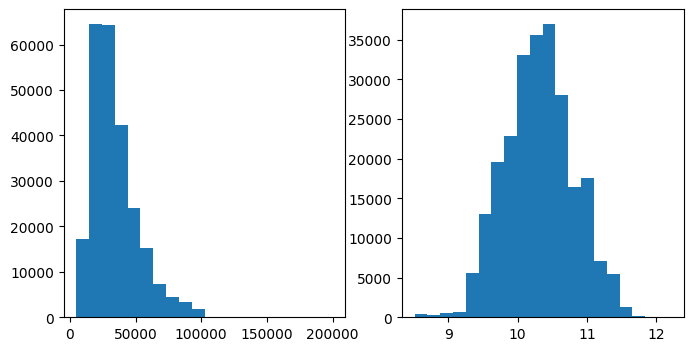

In [9]:
data['Log1pSalary'] = np.log1p(data['SalaryNormalized']).astype('float32')

plt.figure(figsize=[8, 4])
plt.subplot(1, 2, 1)
plt.hist(data["SalaryNormalized"], bins=20);

plt.subplot(1, 2, 2)
plt.hist(data['Log1pSalary'], bins=20);

Our task is to predict one number, __Log1pSalary__.

To do so, our model can access a number of features:
* Free text: __`Title`__ and  __`FullDescription`__
* Categorical: __`Category`__, __`Company`__, __`LocationNormalized`__, __`ContractType`__, and __`ContractTime`__.

In [10]:
text_columns = ["Title", "FullDescription"]
categorical_columns = ["Category", "Company", "LocationNormalized", "ContractType", "ContractTime"]
TARGET_COLUMN = "Log1pSalary"

data[categorical_columns] = data[categorical_columns].fillna('NaN') # cast missing values to string "NaN"

data.sample(3)

,Id,Title,FullDescription,LocationRaw,LocationNormalized,ContractType,ContractTime,Company,Category,SalaryRaw,SalaryNormalized,SourceName,Log1pSalary
211443,72217394,ENGINEERING MANAGER,ENGINEERING MANAGER Military Electronics Loca...,"East of England, Cambridgeshire, South East En...",UK,NaN,NaN,Mana Resourcing,Other/General Jobs,"50,000-74,999 yearly",62499,theladders.co.uk,11.042922
49913,68628257,Drupal Developer/backend/modules/d****,"d****CCK, Views, Panels, Modules, drupal Huntr...",London,London,NaN,contract,Huntress Group Technology Perms,IT Jobs,350.00 - 400.00 GBP Day,90000,jobserve.com,11.407576
66253,68712843,"Finance Litigation Solicitor, Yorkshire",Finance litigation solicitor required for a du...,West Yorkshire Yorkshire,West Yorkshire,NaN,permanent,IPS Group,Legal Jobs,40000.00 - 55000.00 per annum,47500,totaljobs.com,10.768506


### Preprocessing text data

Just like last week, applying NLP to a problem begins from tokenization: splitting raw text into sequences of tokens (words, punctuation, etc).

__Your task__ is to lowercase and tokenize all texts under `Title` and `FullDescription` columns. Store the tokenized data as a __space-separated__ string of tokens for performance reasons.

It's okay to use nltk tokenizers. Assertions were designed for WordPunctTokenizer, slight deviations are okay.

In [11]:
print("Raw text:")
print(data["FullDescription"][2::100000])

Raw text:
2         Mathematical Modeller / Simulation Analyst / O...
100002    A successful and high achieving specialist sch...
200002    Web Designer  HTML, CSS, JavaScript, Photoshop...
Name: FullDescription, dtype: object


In [13]:
import nltk

tokenizer = nltk.tokenize.WordPunctTokenizer()
for col in text_columns:
  data.loc[:, col] = data[col] \
    .fillna('NaN') \
    .apply(lambda x: tokenizer.tokenize(x)) \
    .str.join(' ') \
    .str.lower()

Now we can assume that our text is a space-separated list of tokens:

In [14]:
print("Tokenized:")
print(data["FullDescription"][2::100000])
assert data["FullDescription"][2][:50] == 'mathematical modeller / simulation analyst / opera'
assert data["Title"][54321] == 'international digital account manager ( german )'

Tokenized:
2         mathematical modeller / simulation analyst / o...
100002    a successful and high achieving specialist sch...
200002    web designer html , css , javascript , photosh...
Name: FullDescription, dtype: object


Not all words are equally useful. Some of them are typos or rare words that are only present a few times.

Let's count how many times is each word present in the data so that we can build a "white list" of known words.

In [15]:
from collections import Counter
token_counts = Counter()

# Count how many times does each token occur in both "Title" and "FullDescription" in total
# data[text_columns] \
#   .apply(lambda row : ' '.join(row.values), axis=1) \
#   .str.split(' ')
texts = data['Title'] + ' ' + data['FullDescription']
for i in range(data.shape[0]):
  token_counts.update(texts[i].split(' '))

In [16]:
print("Total unique tokens :", len(token_counts))
print('\n'.join(map(str, token_counts.most_common(n=5))))
print('...')
print('\n'.join(map(str, token_counts.most_common()[-3:])))

assert token_counts.most_common(1)[0][1] in  range(2600000, 2700000)
assert len(token_counts) in range(200000, 210000)
print('Correct!')

Total unique tokens : 202704
('and', 2657388)
('.', 2523216)
(',', 2318606)
('the', 2080994)
('to', 2019884)
...
('stephanietraveltraderecruitmnt', 1)
('ruabon', 1)
('lowehays', 1)
Correct!


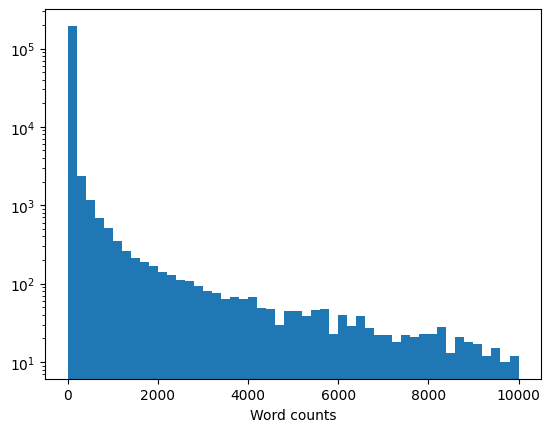

In [17]:
# Let's see how many words are there for each count
plt.hist(list(token_counts.values()), range=[0, 10**4], bins=50, log=True)
plt.xlabel("Word counts");

__Task 1.1__ Get a list of all tokens that occur at least 10 times.

In [18]:
min_count = 10

# tokens from token_counts keys that had at least min_count occurrences throughout the dataset
tokens = [token for token, count in token_counts.items() if count >= min_count]

# Add a special tokens for unknown and empty words
UNK, PAD = "UNK", "PAD"
tokens = [UNK, PAD] + tokens

In [19]:
print("Vocabulary size:", len(tokens))
assert type(tokens) == list
assert len(tokens) in range(32000, 35000)
assert 'me' in tokens
assert UNK in tokens
print("Correct!")

Vocabulary size: 34158
Correct!


__Task 1.2__ Build an inverse token index: a dictionary from token(string) to it's index in `tokens` (int)

In [20]:
%%time
token_to_id = {tokens[index]: index for index in range(len(tokens))}

CPU times: user 6.36 ms, sys: 0 ns, total: 6.36 ms
Wall time: 6.34 ms


In [22]:
assert isinstance(token_to_id, dict)
assert len(token_to_id) == len(tokens)
for tok in tokens:
    assert tokens[token_to_id[tok]] == tok

print("Correct!")

Correct!


And finally, let's use the vocabulary you've built to map text lines into neural network-digestible matrices.

In [23]:
UNK_IX, PAD_IX = map(token_to_id.get, [UNK, PAD])

def as_matrix(sequences, max_len=None):
    """ Convert a list of tokens into a matrix with padding """
    if isinstance(sequences[0], str):
        sequences = list(map(str.split, sequences))

    max_len = min(max(map(len, sequences)), max_len or float('inf'))

    matrix = np.full((len(sequences), max_len), np.int32(PAD_IX))
    for i,seq in enumerate(sequences):
        row_ix = [token_to_id.get(word, UNK_IX) for word in seq[:max_len]]
        matrix[i, :len(row_ix)] = row_ix

    return matrix

In [24]:
print("Lines:")
print('\n'.join(data["Title"][::100000].values), end='\n\n')
print("Matrix:")
print(as_matrix(data["Title"][::100000]))

Lines:
engineering systems analyst
hr assistant
senior ec & i engineer

Matrix:
[[    2     3     4     1     1]
 [  550  2380     1     1     1]
 [  320 10714   392   307    32]]


Now let's  encode the categirical data we have.

As usual, we shall use one-hot encoding for simplicity. Kudos if you implement more advanced encodings: tf-idf, pseudo-time-series, etc.

In [25]:
from sklearn.feature_extraction import DictVectorizer

# we only consider top-1k most frequent companies to minimize memory usage
top_companies, top_counts = zip(*Counter(data['Company']).most_common(1000))
recognized_companies = set(top_companies)
data["Company"] = data["Company"].apply(lambda comp: comp if comp in recognized_companies else "Other")

categorical_vectorizer = DictVectorizer(dtype=np.float32, sparse=False)
categorical_vectorizer.fit(data[categorical_columns].apply(dict, axis=1))

DictVectorizer(dtype=<class 'numpy.float32'>, sparse=False)

### The deep learning part

Once we've learned to tokenize the data, let's design a machine learning experiment.

As before, we won't focus too much on validation, opting for a simple train-test split.

__To be completely rigorous,__ we've comitted a small crime here: we used the whole data for tokenization and vocabulary building. A more strict way would be to do that part on training set only. You may want to do that and measure the magnitude of changes.

In [26]:
from sklearn.model_selection import train_test_split

data_train, data_val = train_test_split(data, test_size=0.2, random_state=42)
data_train.index = range(len(data_train))
data_val.index = range(len(data_val))

print("Train size = ", len(data_train))
print("Validation size = ", len(data_val))

Train size =  195814
Validation size =  48954


In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F


device = 'cuda' if torch.cuda.is_available() else 'cpu'


def to_tensors(batch, device):
    batch_tensors = dict()
    for key, arr in batch.items():
        if key in ["FullDescription", "Title"]:
            batch_tensors[key] = torch.tensor(arr, device=device, dtype=torch.int64)
        else:
            batch_tensors[key] = torch.tensor(arr, device=device)
    return batch_tensors


def make_batch(data, max_len=None, word_dropout=0, device=device):
    """
    Creates a keras-friendly dict from the batch data.
    :param word_dropout: replaces token index with UNK_IX with this probability
    :returns: a dict with {'title' : int64[batch, title_max_len]
    """
    batch = {}
    batch["Title"] = as_matrix(data["Title"].values, max_len)
    batch["FullDescription"] = as_matrix(data["FullDescription"].values, max_len)
    batch['Categorical'] = categorical_vectorizer.transform(data[categorical_columns].apply(dict, axis=1))

    if word_dropout != 0:
        batch["FullDescription"] = apply_word_dropout(batch["FullDescription"], 1. - word_dropout)

    if TARGET_COLUMN in data.columns:
        batch[TARGET_COLUMN] = data[TARGET_COLUMN].values

    return to_tensors(batch, device)

def apply_word_dropout(matrix, keep_prop, replace_with=UNK_IX, pad_ix=PAD_IX,):
    dropout_mask = np.random.choice(2, np.shape(matrix), p=[keep_prop, 1 - keep_prop])
    dropout_mask &= matrix != pad_ix
    return np.choose(dropout_mask, [matrix, np.full_like(matrix, replace_with)])

In [28]:
make_batch(data_train[:3], max_len=10)

{'Title': tensor([[  320,    89,  1657,     1,     1,     1,     1],
         [ 5130,   130,    25,   173,    14,   562, 21820],
         [ 2246,    42,  1433,   109,  9312,  9313,   116]]),
 'FullDescription': tensor([[  320,    89,  1657,  2890,    44,   320,    89,  1657,    12,  2890],
         [ 5130,   130,    25,   173,    14,   562, 21820,  1334,   129,     8],
         [   49,    66,   444,    11,    12,    37,   576,    44,    42,  1433]]),
 'Categorical': tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]),
 'Log1pSalary': tensor([ 9.7115, 10.4631, 10.7144])}

In [75]:
sample_batch = make_batch(data_train[:3], max_len=10)

In [43]:
emb.weight.shape

torch.Size([34158, 10])

In [48]:
b_emb = emb(make_batch(data_train[:3], max_len=10)['Title'])

In [51]:
b_emb[0].shape

torch.Size([7, 10])

In [65]:
conv = nn.Conv1d(10, 20, 3)

In [53]:
conv.weight

Parameter containing:
tensor([[[ 0.1369, -0.0857, -0.0143],
         [-0.1618, -0.1285,  0.1091],
         [ 0.0509, -0.0493,  0.0186],
         [-0.1777,  0.1232, -0.0270],
         [ 0.0233, -0.1002,  0.0371],
         [-0.0397, -0.0655,  0.0115],
         [-0.0303,  0.1734, -0.1451],
         [-0.1813, -0.0306,  0.0614],
         [-0.1275, -0.0366,  0.1525],
         [ 0.1151, -0.0360, -0.1706]],

        [[-0.1768,  0.0823,  0.0776],
         [ 0.0050, -0.1683,  0.0302],
         [-0.0930,  0.0536, -0.1677],
         [ 0.1626,  0.0159, -0.1221],
         [-0.1507, -0.0810,  0.1671],
         [-0.0077,  0.1309,  0.0203],
         [-0.1601,  0.1707,  0.1395],
         [-0.0941, -0.1291, -0.0630],
         [-0.1308, -0.0258,  0.0573],
         [-0.0069, -0.0144, -0.0590]],

        [[ 0.0381,  0.0351,  0.1044],
         [ 0.0205,  0.1286,  0.0372],
         [ 0.0293, -0.1562, -0.0553],
         [ 0.1405, -0.0957, -0.0766],
         [ 0.1605, -0.1660,  0.0373],
         [-0.1502, -0.16

In [59]:
print(b_emb.shape)
print(b_emb.transpose(2, 1).shape)

torch.Size([3, 7, 10])
torch.Size([3, 10, 7])


In [66]:
conv(b_emb.transpose(2, 1)).shape

torch.Size([3, 20, 5])

In [35]:
emb(torch.tensor([[0,1,2,0],[1,1,1,1]]))

tensor([[[ 0.3385, -0.1100],
         [ 2.0227,  2.0474],
         [-1.6199,  0.8575],
         [ 0.3385, -0.1100]],

        [[ 2.0227,  2.0474],
         [ 2.0227,  2.0474],
         [ 2.0227,  2.0474],
         [ 2.0227,  2.0474]]], grad_fn=<EmbeddingBackward0>)

In [ ]:
      desc_emb = nn.Embedding(n_tokens, emb_size)
      desc_emb.weight = title_emb.weight

In [105]:
te = TextEncoder(13, 32)
title_enc = te(sample_batch['Title'])

In [106]:
title_enc

tensor([[0.1951, 0.6245, 0.6230, 0.1375, 0.7242, 0.3748, 0.6869, 0.3789, 0.0264,
         0.5517, 0.7851, 0.9643, 0.4499],
        [1.2528, 0.6140, 0.7655, 0.9139, 0.9398, 0.9646, 0.5420, 0.4981, 0.7707,
         0.0762, 0.4383, 0.3289, 0.2665],
        [0.6958, 1.1063, 1.1347, 0.1554, 0.6921, 0.7819, 0.2042, 0.6201, 0.3849,
         0.2366, 0.4623, 0.6374, 0.2087]], grad_fn=<MaxBackward0>)

In [86]:
title_enc + 1

tensor([[1.7118, 1.9282, 1.6745, 1.3161, 1.6033, 1.5556, 1.2818, 1.4257, 0.8318,
         0.7842, 1.9192, 0.8398, 1.3828],
        [1.7016, 1.3734, 1.9091, 1.3165, 1.9175, 1.1313, 1.7101, 1.2217, 2.1110,
         2.0485, 1.5728, 1.6906, 0.9908],
        [2.0771, 1.5027, 1.3597, 1.8012, 1.6115, 2.0501, 1.5426, 1.6422, 1.5835,
         1.5013, 1.3029, 1.7483, 1.8825]], grad_fn=<AddBackward0>)

In [92]:
title_enc.shape

torch.Size([3, 13])

In [101]:
torch.cat([title_enc, title_enc+1], dim=1)

tensor([[ 0.7118,  0.9282,  0.6745,  0.3161,  0.6033,  0.5556,  0.2818,  0.4257,
         -0.1682, -0.2158,  0.9192, -0.1602,  0.3828,  1.7118,  1.9282,  1.6745,
          1.3161,  1.6033,  1.5556,  1.2818,  1.4257,  0.8318,  0.7842,  1.9192,
          0.8398,  1.3828],
        [ 0.7016,  0.3734,  0.9091,  0.3165,  0.9175,  0.1313,  0.7101,  0.2217,
          1.1110,  1.0485,  0.5728,  0.6906, -0.0092,  1.7016,  1.3734,  1.9091,
          1.3165,  1.9175,  1.1313,  1.7101,  1.2217,  2.1110,  2.0485,  1.5728,
          1.6906,  0.9908],
        [ 1.0771,  0.5027,  0.3597,  0.8012,  0.6115,  1.0501,  0.5426,  0.6422,
          0.5835,  0.5013,  0.3029,  0.7483,  0.8825,  2.0771,  1.5027,  1.3597,
          1.8012,  1.6115,  2.0501,  1.5426,  1.6422,  1.5835,  1.5013,  1.3029,
          1.7483,  1.8825]], grad_fn=<CatBackward0>)

In [95]:
sample_batch['Categorical'].shape

torch.Size([3, 3768])

#### Architecture

Our basic model consists of three branches:
* Title encoder
* Description encoder
* Categorical features encoder

We will then feed all 3 branches into one common network that predicts salary.

![scheme](https://github.com/yandexdataschool/nlp_course/raw/master/resources/w2_conv_arch.png)

In [104]:
class TextEncoder(nn.Module):
    def __init__(self, out_size, emb_size, conv_kernel_size=3, n_tokens=len(tokens), embeddings=None):
        super().__init__()
        if embeddings:
            self.emb = embeddings
        else:
            self.emb = nn.Embedding(n_tokens, emb_size)
        self.conv = nn.Conv1d(emb_size, out_size, kernel_size=conv_kernel_size)

    def forward(self, batch):
        batch_embedded = self.emb(batch).transpose(2, 1)
        batch_conv = self.conv(batch_embedded)
        enc = torch.max(batch_conv, dim=-1).values
        return enc

In [124]:
class SalaryPredictor(nn.Module):
    def __init__(self, n_tokens=len(tokens), n_cat_features=len(categorical_vectorizer.vocabulary_), hid_size=64):
        super().__init__()
        self.title_enc = TextEncoder(hid_size, emb_size=32, conv_kernel_size=3, n_tokens=n_tokens)
        self.desc_enc = TextEncoder(hid_size, emb_size=32, conv_kernel_size=3, n_tokens=n_tokens, embeddings=self.title_enc.emb)
        self.cat_enc = nn.Linear(n_cat_features, hid_size)
        self.head = nn.Linear(3*hid_size, 1)

    def forward(self, batch):
        title_encoded = self.title_enc(batch['Title'])
        desc_encoded = self.desc_enc(batch['FullDescription'])
        cat_encoded = self.cat_enc(batch['Categorical'])
        batch_encoded = torch.cat([title_encoded, desc_encoded, cat_encoded], dim=1)
        preds = self.head(batch_encoded)
        return torch.squeeze(preds)

In [125]:
model = SalaryPredictor()

In [126]:
model = SalaryPredictor().to(device)
batch = make_batch(data_train[:100], device=device)
criterion = nn.MSELoss()

dummy_pred = model(batch)
dummy_loss = criterion(dummy_pred, batch[TARGET_COLUMN])
assert dummy_pred.shape == torch.Size([100])
assert len(torch.unique(dummy_pred)) > 20, "model returns suspiciously few unique outputs. Check your initialization"
assert dummy_loss.ndim == 0 and 0. <= dummy_loss <= 250., "make sure you minimize MSE"

#### Training and evaluation

As usual, we gonna feed our monster with random minibatches of data.

As we train, we want to monitor not only loss function, which is computed in log-space, but also the actual error measured in dollars.

In [127]:
def iterate_minibatches(data, batch_size=256, shuffle=True, cycle=False, device=device, **kwargs):
    """ iterates minibatches of data in random order """
    while True:
        indices = np.arange(len(data))
        if shuffle:
            indices = np.random.permutation(indices)

        for start in range(0, len(indices), batch_size):
            batch = make_batch(data.iloc[indices[start : start + batch_size]], device=device, **kwargs)
            yield batch

        if not cycle: break

### Model training

We can now fit our model the usual minibatch way. The interesting part is that we train on an infinite stream of minibatches, produced by `iterate_minibatches` function.

In [128]:
from tqdm.auto import tqdm

BATCH_SIZE = 16
EPOCHS = 5

In [129]:
def print_metrics(model, data, batch_size=BATCH_SIZE, name="", device=torch.device('cpu'), **kw):
    squared_error = abs_error = num_samples = 0.0
    model.eval()
    with torch.no_grad():
        for batch in iterate_minibatches(data, batch_size=batch_size, shuffle=False, device=device, **kw):
            batch_pred = model(batch)
            squared_error += torch.sum(torch.square(batch_pred - batch[TARGET_COLUMN]))
            abs_error += torch.sum(torch.abs(batch_pred - batch[TARGET_COLUMN]))
            num_samples += len(batch_pred)
    mse = squared_error.detach().cpu().numpy() / num_samples
    mae = abs_error.detach().cpu().numpy() / num_samples
    print("%s results:" % (name or ""))
    print("Mean square error: %.5f" % mse)
    print("Mean absolute error: %.5f" % mae)
    return mse, mae


In [130]:
model = SalaryPredictor().to(device)
criterion = nn.MSELoss(reduction='sum')
optimizer = torch.optim.SGD(model.parameters(), lr=1e-4)

for epoch in range(EPOCHS):
    print(f"epoch: {epoch}")
    model.train()
    for i, batch in tqdm(enumerate(
            iterate_minibatches(data_train, batch_size=BATCH_SIZE, device=device)),
            total=len(data_train) // BATCH_SIZE
        ):
        pred = model(batch)
        loss = criterion(pred, batch[TARGET_COLUMN])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print_metrics(model, data_val, device=device)



epoch: 0


  0%|          | 0/12238 [00:00<?, ?it/s]

 results:
Mean square error: 0.27911
Mean absolute error: 0.43899
epoch: 1


  0%|          | 0/12238 [00:00<?, ?it/s]

 results:
Mean square error: 0.14379
Mean absolute error: 0.29649
epoch: 2


...

 results:
Mean square error: 0.12112
Mean absolute error: 0.26676
epoch: 3


  0%|          | 0/12238 [00:00<?, ?it/s]

 results:
Mean square error: 0.11423
Mean absolute error: 0.25783
epoch: 4


  0%|          | 0/12238 [00:00<?, ?it/s]

 results:
Mean square error: 0.11533
Mean absolute error: 0.26210


### Bonus part: explaining model predictions

It's usually a good idea to understand how your model works before you let it make actual decisions. It's simple for linear models: just see which words learned positive or negative weights. However, its much harder for neural networks that learn complex nonlinear dependencies.

There are, however, some ways to look inside the black box:
* Seeing how model responds to input perturbations
* Finding inputs that maximize/minimize activation of some chosen neurons (_read more [on distill.pub](https://distill.pub/2018/building-blocks/)_)
* Building local linear approximations to your neural network: [article](https://arxiv.org/abs/1602.04938), [eli5 library](https://github.com/TeamHG-Memex/eli5/tree/master/eli5/formatters)

Today we gonna try the first method just because it's the simplest one.

In [ ]:
def explain(model, sample, col_name='Title'):
    """ Computes the effect each word had on model predictions """
    sample = dict(sample)
    sample_col_tokens = [tokens[token_to_id.get(tok, 0)] for tok in sample[col_name].split()]
    data_drop_one_token = pd.DataFrame([sample] * (len(sample_col_tokens) + 1))

    for drop_i in range(len(sample_col_tokens)):
        data_drop_one_token.loc[drop_i, col_name] = ' '.join(UNK if i == drop_i else tok
                                                   for i, tok in enumerate(sample_col_tokens))

    *predictions_drop_one_token, baseline_pred = model(make_batch(data_drop_one_token, device=device)).detach().cpu()
    diffs = baseline_pred - torch.Tensor(predictions_drop_one_token)
    return list(zip(sample_col_tokens, diffs))

In [ ]:
from IPython.display import HTML, display_html


def draw_html(tokens_and_weights, cmap=plt.get_cmap("bwr"), display=True,
              token_template="""<span style="background-color: {color_hex}">{token}</span>""",
              font_style="font-size:14px;"
             ):

    def get_color_hex(weight):
        rgba = cmap(1. / (1 + np.exp(float(weight))), bytes=True)
        return '#%02X%02X%02X' % rgba[:3]

    tokens_html = [
        token_template.format(token=token, color_hex=get_color_hex(weight))
        for token, weight in tokens_and_weights
    ]


    raw_html = """<p style="{}">{}</p>""".format(font_style, ' '.join(tokens_html))
    if display:
        display_html(HTML(raw_html))

    return raw_html


In [ ]:
i = 36605
tokens_and_weights = explain(model, data.loc[i], "Title")
draw_html([(tok, weight * 5) for tok, weight in tokens_and_weights], font_style='font-size:20px;');

tokens_and_weights = explain(model, data.loc[i], "FullDescription")
draw_html([(tok, weight * 10) for tok, weight in tokens_and_weights]);

In [ ]:
i = 12077
tokens_and_weights = explain(model, data.loc[i], "Title")
draw_html([(tok, weight * 5) for tok, weight in tokens_and_weights], font_style='font-size:20px;');

tokens_and_weights = explain(model, data.loc[i], "FullDescription")
draw_html([(tok, weight * 10) for tok, weight in tokens_and_weights]);

In [ ]:
i = np.random.randint(len(data))
print("Index:", i)
print("Salary (gbp):", np.expm1(model(make_batch(data.iloc[i: i+1], device=device)).detach().cpu()))

tokens_and_weights = explain(model, data.loc[i], "Title")
draw_html([(tok, weight * 5) for tok, weight in tokens_and_weights], font_style='font-size:20px;');

tokens_and_weights = explain(model, data.loc[i], "FullDescription")
draw_html([(tok, weight * 10) for tok, weight in tokens_and_weights]);

## Preparation


In [1]:
!pip install gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 769.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 13.8 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.14.1
    Uninstalling scipy-1.14.1:
      Successfully uninstalled scipy-1.14.1


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from collections import Counter
from sklearn.feature_extraction import DictVectorizer
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
import gensim.downloader

import torch
import torch.nn as nn
import torch.nn.functional as F

%matplotlib inline

In [3]:
!mkdir --parents ~/.config/kaggle
!mv kaggle.json ~/.config/kaggle/kaggle.json
!chmod 600 /root/.config/kaggle/kaggle.json
!kaggle competitions download -c job-salary-prediction
!unzip job-salary-prediction.zip

100% 318M/318M [00:18<00:00, 22.0MB/s]
100% 318M/318M [00:18<00:00, 18.3MB/s]
Archive:  job-salary-prediction.zip
  inflating: Location_Tree.csv       
  inflating: Test_rev1.7z            
  inflating: Test_rev1.zip           
  inflating: Train_rev1.7z           
  inflating: Train_rev1.zip          
  inflating: Valid_rev1.7z           
  inflating: Valid_rev1.csv          
  inflating: mean_benchmark.csv      
  inflating: random_forest_benchmark_test_rev1.csv  
  inflating: test.csv                


In [4]:
data = pd.read_csv("./Train_rev1.zip", compression='zip', index_col=None)
print(data.shape)

data['Log1pSalary'] = np.log1p(data['SalaryNormalized']).astype('float32')

text_columns = ["Title", "FullDescription"]
categorical_columns = ["Category", "Company", "LocationNormalized", "ContractType", "ContractTime"]
TARGET_COLUMN = "Log1pSalary"

data[categorical_columns] = data[categorical_columns].fillna('NaN') # cast missing values to string "NaN"



tokenizer = nltk.tokenize.WordPunctTokenizer()
for col in text_columns:
  data.loc[:, col] = data[col] \
    .fillna('NaN') \
    .apply(lambda x: tokenizer.tokenize(x)) \
    .str.join(' ') \
    .str.lower()

assert data["FullDescription"][2][:50] == 'mathematical modeller / simulation analyst / opera'
assert data["Title"][54321] == 'international digital account manager ( german )'



token_counts = Counter()
texts = data['Title'] + ' ' + data['FullDescription']
for i in range(data.shape[0]):
  token_counts.update(texts[i].split(' '))

assert token_counts.most_common(1)[0][1] in  range(2600000, 2700000)
assert len(token_counts) in range(200000, 210000)



min_count = 10
# tokens from token_counts keys that had at least min_count occurrences throughout the dataset
tokens = [token for token, count in token_counts.items() if count >= min_count]
# Add a special tokens for unknown and empty words
UNK, PAD = "UNK", "PAD"
tokens = [UNK, PAD] + tokens

assert type(tokens) == list
assert len(tokens) in range(32000, 35000)
assert 'me' in tokens
assert UNK in tokens



token_to_id = {tokens[index]: index for index in range(len(tokens))}
assert isinstance(token_to_id, dict)
assert len(token_to_id) == len(tokens)
for tok in tokens:
    assert tokens[token_to_id[tok]] == tok



UNK_IX, PAD_IX = map(token_to_id.get, [UNK, PAD])

def as_matrix(sequences, max_len=None):
    """ Convert a list of tokens into a matrix with padding """
    if isinstance(sequences[0], str):
        sequences = list(map(str.split, sequences))

    max_len = min(max(map(len, sequences)), max_len or float('inf'))

    matrix = np.full((len(sequences), max_len), np.int32(PAD_IX))
    for i,seq in enumerate(sequences):
        row_ix = [token_to_id.get(word, UNK_IX) for word in seq[:max_len]]
        matrix[i, :len(row_ix)] = row_ix

    return matrix

# we only consider top-1k most frequent companies to minimize memory usage
top_companies, top_counts = zip(*Counter(data['Company']).most_common(1000))
recognized_companies = set(top_companies)
data["Company"] = data["Company"].apply(lambda comp: comp if comp in recognized_companies else "Other")

categorical_vectorizer = DictVectorizer(dtype=np.float32, sparse=False)
categorical_vectorizer.fit(data[categorical_columns].apply(dict, axis=1))

(244768, 12)


DictVectorizer(dtype=<class 'numpy.float32'>, sparse=False)

In [5]:
data_train, data_val = train_test_split(data, test_size=0.2, random_state=42)
data_train.index = range(len(data_train))
data_val.index = range(len(data_val))

print("Train size = ", len(data_train))
print("Validation size = ", len(data_val))

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

def to_tensors(batch, device):
    batch_tensors = dict()
    for key, arr in batch.items():
        if key in ["FullDescription", "Title"]:
            batch_tensors[key] = torch.tensor(arr, device=device, dtype=torch.int64)
        else:
            batch_tensors[key] = torch.tensor(arr, device=device)
    return batch_tensors


def make_batch(data, max_len=None, word_dropout=0, device=device):
    """
    Creates a keras-friendly dict from the batch data.
    :param word_dropout: replaces token index with UNK_IX with this probability
    :returns: a dict with {'title' : int64[batch, title_max_len]
    """
    batch = {}
    batch["Title"] = as_matrix(data["Title"].values, max_len)
    batch["FullDescription"] = as_matrix(data["FullDescription"].values, max_len)
    batch['Categorical'] = categorical_vectorizer.transform(data[categorical_columns].apply(dict, axis=1))

    if word_dropout != 0:
        batch["FullDescription"] = apply_word_dropout(batch["FullDescription"], 1. - word_dropout)

    if TARGET_COLUMN in data.columns:
        batch[TARGET_COLUMN] = data[TARGET_COLUMN].values

    return to_tensors(batch, device)

def apply_word_dropout(matrix, keep_prop, replace_with=UNK_IX, pad_ix=PAD_IX,):
    dropout_mask = np.random.choice(2, np.shape(matrix), p=[keep_prop, 1 - keep_prop])
    dropout_mask &= matrix != pad_ix
    return np.choose(dropout_mask, [matrix, np.full_like(matrix, replace_with)])


def iterate_minibatches(data, batch_size=256, shuffle=True, cycle=False, device=device, **kwargs):
    """ iterates minibatches of data in random order """
    while True:
        indices = np.arange(len(data))
        if shuffle:
            indices = np.random.permutation(indices)

        for start in range(0, len(indices), batch_size):
            batch = make_batch(data.iloc[indices[start : start + batch_size]], device=device, **kwargs)
            yield batch

        if not cycle: break

BATCH_SIZE = 16
def print_metrics(model, data, batch_size=BATCH_SIZE, name="", device=torch.device('cpu'), **kw):
    squared_error = abs_error = num_samples = 0.0
    model.eval()
    with torch.no_grad():
        for batch in iterate_minibatches(data, batch_size=batch_size, shuffle=False, device=device, **kw):
            batch_pred = model(batch)
            squared_error += torch.sum(torch.square(batch_pred - batch[TARGET_COLUMN]))
            abs_error += torch.sum(torch.abs(batch_pred - batch[TARGET_COLUMN]))
            num_samples += len(batch_pred)
    mse = squared_error.detach().cpu().numpy() / num_samples
    mae = abs_error.detach().cpu().numpy() / num_samples
    print("%s results:" % (name or ""))
    print("Mean square error: %.5f" % mse)
    print("Mean absolute error: %.5f" % mae)
    return mse, mae


Train size =  195814
Validation size =  48954
Device: cuda


## Baseline

In [6]:
class TextEncoder(nn.Module):
    def __init__(self, out_size, emb_size, conv_kernel_size=3, n_tokens=len(tokens), embeddings=None):
        super().__init__()
        if embeddings:
            self.emb = embeddings
        else:
            self.emb = nn.Embedding(n_tokens, emb_size)
        self.conv = nn.Conv1d(emb_size, out_size, kernel_size=conv_kernel_size)

    def forward(self, batch):
        batch_embedded = self.emb(batch).transpose(2, 1)
        batch_conv = self.conv(batch_embedded)
        enc = torch.max(batch_conv, dim=-1).values
        return enc

class SalaryPredictor(nn.Module):
    def __init__(self, n_tokens=len(tokens), n_cat_features=len(categorical_vectorizer.vocabulary_), hid_size=64):
        super().__init__()
        self.title_enc = TextEncoder(hid_size, emb_size=32, conv_kernel_size=3, n_tokens=n_tokens)
        self.desc_enc = TextEncoder(hid_size, emb_size=32, conv_kernel_size=3, n_tokens=n_tokens, embeddings=self.title_enc.emb)
        self.cat_enc = nn.Linear(n_cat_features, hid_size)
        self.head = nn.Linear(3*hid_size, 1)

    def forward(self, batch):
        title_encoded = self.title_enc(batch['Title'])
        desc_encoded = self.desc_enc(batch['FullDescription'])
        cat_encoded = self.cat_enc(batch['Categorical'])
        batch_encoded = torch.cat([title_encoded, desc_encoded, cat_encoded], dim=1)
        preds = self.head(batch_encoded)
        return torch.squeeze(preds)

In [7]:
model = SalaryPredictor().to(device)
batch = make_batch(data_train[:100], device=device)
criterion = nn.MSELoss()

dummy_pred = model(batch)
dummy_loss = criterion(dummy_pred, batch[TARGET_COLUMN])
assert dummy_pred.shape == torch.Size([100])
assert len(torch.unique(dummy_pred)) > 20, "model returns suspiciously few unique outputs. Check your initialization"
assert dummy_loss.ndim == 0 and 0. <= dummy_loss <= 250., "make sure you minimize MSE"

In [ ]:
BATCH_SIZE = 128
EPOCHS = 5

model = SalaryPredictor().to(device)
criterion = nn.MSELoss(reduction='sum')
optimizer = torch.optim.SGD(model.parameters(), lr=1e-4)

for epoch in range(EPOCHS):
    print(f"epoch: {epoch}")
    model.train()
    for i, batch in tqdm(enumerate(
            iterate_minibatches(data_train, batch_size=BATCH_SIZE, device=device)),
            total=len(data_train) // BATCH_SIZE
        ):
        pred = model(batch)
        loss = criterion(pred, batch[TARGET_COLUMN])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print_metrics(model, data_val, device=device)


## Experiments

### мини-исследование про размер батча


In [ ]:
BATCH_SIZE = 8
EPOCHS = 2

pretrained_emb_weights = torch.FloatTensor(embeddings.vectors)
model = SalaryPredictor(pretrained_emb_weights).to(device)
criterion = nn.MSELoss(reduction='sum')
optimizer = torch.optim.SGD(model.parameters(), lr=1e-4)

for epoch in range(EPOCHS):
    print(f"epoch: {epoch}")
    model.train()
    for i, batch in tqdm(enumerate(
            iterate_minibatches(data_train, batch_size=BATCH_SIZE, device=device)),
            total=len(data_train) // BATCH_SIZE
        ):
        pred = model(batch)
        loss = criterion(pred, batch[TARGET_COLUMN])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print_metrics(model, data_val, device=device)


epoch: 0


  0%|          | 0/24476 [00:00<?, ?it/s]

 results:
Mean square error: 0.15843
Mean absolute error: 0.30815
epoch: 1


  0%|          | 0/24476 [00:00<?, ?it/s]

 results:
Mean square error: 0.13519
Mean absolute error: 0.28155


In [ ]:
BATCH_SIZE = 16
EPOCHS = 2

pretrained_emb_weights = torch.FloatTensor(embeddings.vectors)
model = SalaryPredictor(pretrained_emb_weights).to(device)
criterion = nn.MSELoss(reduction='sum')
optimizer = torch.optim.SGD(model.parameters(), lr=1e-4)

for epoch in range(EPOCHS):
    print(f"epoch: {epoch}")
    model.train()
    for i, batch in tqdm(enumerate(
            iterate_minibatches(data_train, batch_size=BATCH_SIZE, device=device)),
            total=len(data_train) // BATCH_SIZE
        ):
        pred = model(batch)
        loss = criterion(pred, batch[TARGET_COLUMN])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print_metrics(model, data_val, device=device)


epoch: 0


  0%|          | 0/12238 [00:00<?, ?it/s]

 results:
Mean square error: 0.16362
Mean absolute error: 0.31369
epoch: 1


  0%|          | 0/12238 [00:00<?, ?it/s]

 results:
Mean square error: 0.13784
Mean absolute error: 0.28566


In [ ]:
BATCH_SIZE = 32
EPOCHS = 2

pretrained_emb_weights = torch.FloatTensor(embeddings.vectors)
model = SalaryPredictor(pretrained_emb_weights).to(device)
criterion = nn.MSELoss(reduction='sum')
optimizer = torch.optim.SGD(model.parameters(), lr=1e-4)

for epoch in range(EPOCHS):
    print(f"epoch: {epoch}")
    model.train()
    for i, batch in tqdm(enumerate(
            iterate_minibatches(data_train, batch_size=BATCH_SIZE, device=device)),
            total=len(data_train) // BATCH_SIZE
        ):
        pred = model(batch)
        loss = criterion(pred, batch[TARGET_COLUMN])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print_metrics(model, data_val, device=device)


epoch: 0


  0%|          | 0/6119 [00:00<?, ?it/s]

 results:
Mean square error: 0.16702
Mean absolute error: 0.31952
epoch: 1


  0%|          | 0/6119 [00:00<?, ?it/s]

 results:
Mean square error: 0.14143
Mean absolute error: 0.29154


In [ ]:
BATCH_SIZE = 64
EPOCHS = 2

pretrained_emb_weights = torch.FloatTensor(embeddings.vectors)
model = SalaryPredictor(pretrained_emb_weights).to(device)
criterion = nn.MSELoss(reduction='sum')
optimizer = torch.optim.SGD(model.parameters(), lr=1e-4)

for epoch in range(EPOCHS):
    print(f"epoch: {epoch}")
    model.train()
    for i, batch in tqdm(enumerate(
            iterate_minibatches(data_train, batch_size=BATCH_SIZE, device=device)),
            total=len(data_train) // BATCH_SIZE
        ):
        pred = model(batch)
        loss = criterion(pred, batch[TARGET_COLUMN])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print_metrics(model, data_val, device=device)


epoch: 0


  0%|          | 0/3059 [00:00<?, ?it/s]

 results:
Mean square error: 0.17374
Mean absolute error: 0.32319
epoch: 1


  0%|          | 0/3059 [00:00<?, ?it/s]

 results:
Mean square error: 0.14557
Mean absolute error: 0.29286


In [ ]:
BATCH_SIZE = 128
EPOCHS = 2

pretrained_emb_weights = torch.FloatTensor(embeddings.vectors)
model = SalaryPredictor(pretrained_emb_weights).to(device)
criterion = nn.MSELoss(reduction='sum')
optimizer = torch.optim.SGD(model.parameters(), lr=1e-4)

for epoch in range(EPOCHS):
    print(f"epoch: {epoch}")
    model.train()
    for i, batch in tqdm(enumerate(
            iterate_minibatches(data_train, batch_size=BATCH_SIZE, device=device)),
            total=len(data_train) // BATCH_SIZE
        ):
        pred = model(batch)
        loss = criterion(pred, batch[TARGET_COLUMN])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print_metrics(model, data_val, device=device)


epoch: 0


  0%|          | 0/1529 [00:00<?, ?it/s]

 results:
Mean square error: 0.19132
Mean absolute error: 0.33603
epoch: 1


  0%|          | 0/1529 [00:00<?, ?it/s]

 results:
Mean square error: 0.15804
Mean absolute error: 0.30381


In [ ]:
BATCH_SIZE = 256
EPOCHS = 2

pretrained_emb_weights = torch.FloatTensor(embeddings.vectors)
model = SalaryPredictor(pretrained_emb_weights).to(device)
criterion = nn.MSELoss(reduction='sum')
optimizer = torch.optim.SGD(model.parameters(), lr=1e-4)

for epoch in range(EPOCHS):
    print(f"epoch: {epoch}")
    model.train()
    for i, batch in tqdm(enumerate(
            iterate_minibatches(data_train, batch_size=BATCH_SIZE, device=device)),
            total=len(data_train) // BATCH_SIZE
        ):
        pred = model(batch)
        loss = criterion(pred, batch[TARGET_COLUMN])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print_metrics(model, data_val, device=device)


epoch: 0


  0%|          | 0/764 [00:00<?, ?it/s]

 results:
Mean square error: 0.18956
Mean absolute error: 0.33445
epoch: 1


  0%|          | 0/764 [00:00<?, ?it/s]

 results:
Mean square error: 0.14495
Mean absolute error: 0.29302


In [ ]:
BATCH_SIZE = 512
EPOCHS = 2

pretrained_emb_weights = torch.FloatTensor(embeddings.vectors)
model = SalaryPredictor(pretrained_emb_weights).to(device)
criterion = nn.MSELoss(reduction='sum')
optimizer = torch.optim.SGD(model.parameters(), lr=1e-4)

for epoch in range(EPOCHS):
    print(f"epoch: {epoch}")
    model.train()
    for i, batch in tqdm(enumerate(
            iterate_minibatches(data_train, batch_size=BATCH_SIZE, device=device)),
            total=len(data_train) // BATCH_SIZE
        ):
        pred = model(batch)
        loss = criterion(pred, batch[TARGET_COLUMN])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print_metrics(model, data_val, device=device)


epoch: 0


  0%|          | 0/382 [00:00<?, ?it/s]

 results:
Mean square error: nan
Mean absolute error: nan
epoch: 1


  0%|          | 0/382 [00:00<?, ?it/s]

 results:
Mean square error: nan
Mean absolute error: nan


### Pretrained embeddings


In [12]:
gensim.downloader.info()['models'].keys()

dict_keys(['fasttext-wiki-news-subwords-300', 'conceptnet-numberbatch-17-06-300', 'word2vec-ruscorpora-300', 'word2vec-google-news-300', 'glove-wiki-gigaword-50', 'glove-wiki-gigaword-100', 'glove-wiki-gigaword-200', 'glove-wiki-gigaword-300', 'glove-twitter-25', 'glove-twitter-50', 'glove-twitter-100', 'glove-twitter-200', '__testing_word2vec-matrix-synopsis'])

#### GloVe

In [9]:
embeddings = gensim.downloader.load("fasttext-wiki-news-subwords-300")

[==================================================] 100.0% 958.5/958.4MB downloaded


In [10]:
print(f"Dict size baseline: {len(tokens)}")
print(f"Dict size fasttext-wiki-news-subwords-300: {embeddings.vectors.shape[0]}")

Dict size baseline: 34158
Dict size fasttext-wiki-news-subwords-300: 999999


In [11]:
UNK_IX, PAD_IX = map(embeddings.get_index, [UNK, PAD])

def as_matrix_emb(sequences, max_len=None):
    """ Convert a list of tokens into a matrix with padding """
    if isinstance(sequences[0], str):
        sequences = list(map(str.split, sequences))

    max_len = min(max(map(len, sequences)), max_len or float('inf'))

    matrix = np.full((len(sequences), max_len), np.int32(PAD_IX))
    for i,seq in enumerate(sequences):
        row_ix = [embeddings.get_index(word, UNK_IX) for word in seq[:max_len]]
        matrix[i, :len(row_ix)] = row_ix

    return matrix


def make_batch(data, max_len=None, word_dropout=0, device=device):
    """
    Creates a keras-friendly dict from the batch data.
    :param word_dropout: replaces token index with UNK_IX with this probability
    :returns: a dict with {'title' : int64[batch, title_max_len]
    """
    batch = {}
    batch["Title"] = as_matrix_emb(data["Title"].values, max_len)
    batch["FullDescription"] = as_matrix_emb(data["FullDescription"].values, max_len)
    batch['Categorical'] = categorical_vectorizer.transform(data[categorical_columns].apply(dict, axis=1))

    if word_dropout != 0:
        batch["FullDescription"] = apply_word_dropout(batch["FullDescription"], 1. - word_dropout)

    if TARGET_COLUMN in data.columns:
        batch[TARGET_COLUMN] = data[TARGET_COLUMN].values

    return to_tensors(batch, device)

In [12]:
class TextEncoderPretrained(nn.Module):
    def __init__(self, emb_weights, out_size, conv_kernel_size=3):
        super().__init__()
        self.emb = nn.Embedding.from_pretrained(emb_weights)
        self.conv = nn.Conv1d(self.emb.embedding_dim, out_size, kernel_size=conv_kernel_size)

    def forward(self, batch):
        batch_embedded = self.emb(batch).transpose(2, 1)
        batch_conv = self.conv(batch_embedded)
        enc = torch.max(batch_conv, dim=-1).values
        return enc

class SalaryPredictor(nn.Module):
    def __init__(self, emb_weights, n_cat_features=len(categorical_vectorizer.vocabulary_), hid_size=64):
        super().__init__()
        self.title_enc = TextEncoderPretrained(emb_weights, hid_size, conv_kernel_size=3)
        self.desc_enc = TextEncoderPretrained(emb_weights, hid_size, conv_kernel_size=3)
        self.cat_enc = nn.Linear(n_cat_features, hid_size)
        self.head = nn.Linear(3*hid_size, 1)

    def forward(self, batch):
        title_encoded = self.title_enc(batch['Title'])
        desc_encoded = self.desc_enc(batch['FullDescription'])
        cat_encoded = self.cat_enc(batch['Categorical'])
        batch_encoded = torch.cat([title_encoded, desc_encoded, cat_encoded], dim=1)
        preds = self.head(batch_encoded)
        return torch.squeeze(preds)

In [ ]:
BATCH_SIZE = 128
EPOCHS = 15

pretrained_emb_weights = torch.FloatTensor(embeddings.vectors)
model = SalaryPredictor(pretrained_emb_weights).to(device)
criterion = nn.MSELoss(reduction='sum')
optimizer = torch.optim.SGD(model.parameters(), lr=1e-4)

for epoch in range(EPOCHS):
    print(f"epoch: {epoch}")
    model.train()
    for i, batch in tqdm(enumerate(
            iterate_minibatches(data_train, batch_size=BATCH_SIZE, device=device)),
            total=len(data_train) // BATCH_SIZE
        ):
        pred = model(batch)
        loss = criterion(pred, batch[TARGET_COLUMN])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print_metrics(model, data_val, device=device)


epoch: 0


  0%|          | 0/1529 [00:00<?, ?it/s]

 results:
Mean square error: 0.20201
Mean absolute error: 0.34553
epoch: 1


  0%|          | 0/1529 [00:00<?, ?it/s]

 results:
Mean square error: 0.16287
Mean absolute error: 0.30899
epoch: 2


...

 results:
Mean square error: 0.09007
Mean absolute error: 0.22655
epoch: 13


  0%|          | 0/1529 [00:00<?, ?it/s]

 results:
Mean square error: 0.08900
Mean absolute error: 0.22510
epoch: 14


  0%|          | 0/1529 [00:00<?, ?it/s]

 results:
Mean square error: 0.08845
Mean absolute error: 0.22246


#### Fasttext

In [12]:
embeddings = gensim.downloader.load("glove-wiki-gigaword-300")

[==================================================] 100.0% 376.1/376.1MB downloaded


In [13]:
UNK_IX, PAD_IX = map(embeddings.get_index, [UNK, PAD])

def as_matrix_emb(sequences, max_len=None):
    """ Convert a list of tokens into a matrix with padding """
    if isinstance(sequences[0], str):
        sequences = list(map(str.split, sequences))

    max_len = min(max(map(len, sequences)), max_len or float('inf'))

    matrix = np.full((len(sequences), max_len), np.int32(PAD_IX))
    for i,seq in enumerate(sequences):
        row_ix = [embeddings.get_index(word, UNK_IX) for word in seq[:max_len]]
        matrix[i, :len(row_ix)] = row_ix

    return matrix


def make_batch(data, max_len=None, word_dropout=0, device=device):
    """
    Creates a keras-friendly dict from the batch data.
    :param word_dropout: replaces token index with UNK_IX with this probability
    :returns: a dict with {'title' : int64[batch, title_max_len]
    """
    batch = {}
    batch["Title"] = as_matrix_emb(data["Title"].values, max_len)
    batch["FullDescription"] = as_matrix_emb(data["FullDescription"].values, max_len)
    batch['Categorical'] = categorical_vectorizer.transform(data[categorical_columns].apply(dict, axis=1))

    if word_dropout != 0:
        batch["FullDescription"] = apply_word_dropout(batch["FullDescription"], 1. - word_dropout)

    if TARGET_COLUMN in data.columns:
        batch[TARGET_COLUMN] = data[TARGET_COLUMN].values

    return to_tensors(batch, device)

KeyError: "Key 'UNK' not present"

In [ ]:
UNK_IX, PAD_IX

In [ ]:
class TextEncoderPretrained(nn.Module):
    def __init__(self, emb_weights, out_size, conv_kernel_size=3):
        super().__init__()
        self.emb = nn.Embedding.from_pretrained(emb_weights)
        self.conv = nn.Conv1d(self.emb.embedding_dim, out_size, kernel_size=conv_kernel_size)

    def forward(self, batch):
        batch_embedded = self.emb(batch).transpose(2, 1)
        batch_conv = self.conv(batch_embedded)
        enc = torch.max(batch_conv, dim=-1).values
        return enc

class SalaryPredictor(nn.Module):
    def __init__(self, emb_weights, n_cat_features=len(categorical_vectorizer.vocabulary_), hid_size=64):
        super().__init__()
        self.title_enc = TextEncoderPretrained(emb_weights, hid_size, conv_kernel_size=3)
        self.desc_enc = TextEncoderPretrained(emb_weights, hid_size, conv_kernel_size=3)
        self.cat_enc = nn.Linear(n_cat_features, hid_size)
        self.head = nn.Linear(3*hid_size, 1)

    def forward(self, batch):
        title_encoded = self.title_enc(batch['Title'])
        desc_encoded = self.desc_enc(batch['FullDescription'])
        cat_encoded = self.cat_enc(batch['Categorical'])
        batch_encoded = torch.cat([title_encoded, desc_encoded, cat_encoded], dim=1)
        preds = self.head(batch_encoded)
        return torch.squeeze(preds)

In [ ]:
BATCH_SIZE = 128
EPOCHS = 15

pretrained_emb_weights = torch.FloatTensor(embeddings.vectors)
model = SalaryPredictor(pretrained_emb_weights).to(device)
criterion = nn.MSELoss(reduction='sum')
optimizer = torch.optim.SGD(model.parameters(), lr=1e-4)

for epoch in range(EPOCHS):
    print(f"epoch: {epoch}")
    model.train()
    for i, batch in tqdm(enumerate(
            iterate_minibatches(data_train, batch_size=BATCH_SIZE, device=device)),
            total=len(data_train) // BATCH_SIZE
        ):
        pred = model(batch)
        loss = criterion(pred, batch[TARGET_COLUMN])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print_metrics(model, data_val, device=device)


epoch: 0


  0%|          | 0/1529 [00:00<?, ?it/s]

 results:
Mean square error: 0.20201
Mean absolute error: 0.34553
epoch: 1


  0%|          | 0/1529 [00:00<?, ?it/s]

 results:
Mean square error: 0.16287
Mean absolute error: 0.30899
epoch: 2


...

 results:
Mean square error: 0.09007
Mean absolute error: 0.22655
epoch: 13


  0%|          | 0/1529 [00:00<?, ?it/s]

 results:
Mean square error: 0.08900
Mean absolute error: 0.22510
epoch: 14


  0%|          | 0/1529 [00:00<?, ?it/s]

 results:
Mean square error: 0.08845
Mean absolute error: 0.22246


### CNN architecture

#### word dropouts


In [15]:
BATCH_SIZE = 128
EPOCHS = 30

pretrained_emb_weights = torch.FloatTensor(embeddings.vectors)
model = SalaryPredictor(pretrained_emb_weights).to(device)
criterion = nn.MSELoss(reduction='sum')
optimizer = torch.optim.SGD(model.parameters(), lr=1e-4)

for epoch in range(EPOCHS):
    print(f"epoch: {epoch}")
    model.train()
    for i, batch in tqdm(enumerate(
            iterate_minibatches(data_train, batch_size=BATCH_SIZE, device=device, word_dropout=0.1)),
            total=len(data_train) // BATCH_SIZE
        ):
        pred = model(batch)
        loss = criterion(pred, batch[TARGET_COLUMN])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print_metrics(model, data_val, device=device)

epoch: 0


  0%|          | 0/1529 [00:00<?, ?it/s]

 results:
Mean square error: 1.23259
Mean absolute error: 0.95959
epoch: 1


  0%|          | 0/1529 [00:00<?, ?it/s]

 results:
Mean square error: 1.02841
Mean absolute error: 0.86196
epoch: 2


...

 results:
Mean square error: 0.44235
Mean absolute error: 0.55541
epoch: 28


  0%|          | 0/1529 [00:00<?, ?it/s]

 results:
Mean square error: 0.42014
Mean absolute error: 0.53906
epoch: 29


  0%|          | 0/1529 [00:00<?, ?it/s]

 results:
Mean square error: 0.43760
Mean absolute error: 0.55476


In [ ]:
class TextEncoderPretrained(nn.Module):
    def __init__(self, emb_weights, out_size, conv_kernel_size=3):
        super().__init__()
        self.emb = nn.Embedding.from_pretrained(emb_weights)
        self.conv = nn.Conv1d(self.emb.embedding_dim, out_size, kernel_size=conv_kernel_size)

    def forward(self, batch):
        batch_embedded = self.emb(batch).transpose(2, 1)
        batch_conv = self.conv(batch_embedded)
        enc = torch.max(batch_conv, dim=-1).values
        return enc

class SalaryPredictor(nn.Module):
    def __init__(self, emb_weights, n_cat_features=len(categorical_vectorizer.vocabulary_), hid_size=64):
        super().__init__()
        self.title_enc = TextEncoderPretrained(emb_weights, hid_size, conv_kernel_size=3)
        self.desc_enc = TextEncoderPretrained(emb_weights, hid_size, conv_kernel_size=3)
        self.cat_enc = nn.Linear(n_cat_features, hid_size)
        self.head = nn.Linear(3*hid_size, 1)

    def forward(self, batch):
        title_encoded = self.title_enc(batch['Title'])
        desc_encoded = self.desc_enc(batch['FullDescription'])
        cat_encoded = self.cat_enc(batch['Categorical'])
        batch_encoded = torch.cat([title_encoded, desc_encoded, cat_encoded], dim=1)
        preds = self.head(batch_encoded)
        return torch.squeeze(preds)

## A short report

Please tell us what you did and how did it work.

`<YOUR_TEXT_HERE>`, i guess...

## Recommended options

#### A) CNN architecture

All the tricks you know about dense and convolutional neural networks apply here as well.
* Dropout. Nuff said.
* Batch Norm. This time it's `nn.BatchNorm*`/`L.BatchNormalization`
* Parallel convolution layers. The idea is that you apply several nn.Conv1d to the same embeddings and concatenate output channels.
* More layers, more neurons, ya know...


#### B) Play with pooling

There's more than one way to perform pooling:
* Max over time (independently for each feature)
* Average over time (excluding PAD)
* Softmax-pooling:
$$ out_{i, t} = \sum_t {h_{i,t} \cdot {{e ^ {h_{i, t}}} \over \sum_\tau e ^ {h_{j, \tau}} } }$$

* Attentive pooling
$$ out_{i, t} = \sum_t {h_{i,t} \cdot Attn(h_t)}$$

, where $$ Attn(h_t) = {{e ^ {NN_{attn}(h_t)}} \over \sum_\tau e ^ {NN_{attn}(h_\tau)}}  $$
and $NN_{attn}$ is a dense layer.

The optimal score is usually achieved by concatenating several different poolings, including several attentive pooling with different $NN_{attn}$ (aka multi-headed attention).

The catch is that keras layers do not inlude those toys. You will have to [write your own keras layer](https://keras.io/layers/writing-your-own-keras-layers/). Or use pure tensorflow, it might even be easier :)

#### C) Fun with words

It's not always a good idea to train embeddings from scratch. Here's a few tricks:

* Use a pre-trained embeddings from `gensim.downloader.load`. See last lecture.
* Start with pre-trained embeddings, then fine-tune them with gradient descent. You may or may not download pre-trained embeddings from [here](http://nlp.stanford.edu/data/glove.6B.zip) and follow this [manual](https://keras.io/examples/nlp/pretrained_word_embeddings/) to initialize your Keras embedding layer with downloaded weights.
* Use the same embedding matrix in title and desc vectorizer


#### D) Going recurrent

We've already learned that recurrent networks can do cool stuff in sequence modelling. Turns out, they're not useless for classification as well. With some tricks of course..

* Like convolutional layers, LSTM should be pooled into a fixed-size vector with some of the poolings.
* Since you know all the text in advance, use bidirectional RNN
  * Run one LSTM from left to right
  * Run another in parallel from right to left
  * Concatenate their output sequences along unit axis (dim=-1)

* It might be good idea to mix convolutions and recurrent layers differently for title and description


#### E) Optimizing seriously

* You don't necessarily need 100 epochs. Use early stopping. If you've never done this before, take a look at [early stopping callback(keras)](https://keras.io/callbacks/#earlystopping) or in [pytorch(lightning)](https://pytorch-lightning.readthedocs.io/en/latest/common/early_stopping.html).
  * In short, train until you notice that validation
  * Maintain the best-on-validation snapshot via `model.save(file_name)`
  * Plotting learning curves is usually a good idea
  
Good luck! And may the force be with you!